In [1]:
!pip install Tensorflow

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
mnist=keras.datasets.mnist

In [4]:
(x_train, y_train), (x_test, y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
x_train, x_test=x_train/255.0, x_test/255.0

In [6]:
import matplotlib.pyplot as plt

In [35]:
x_train[9999].shape

(28, 28)

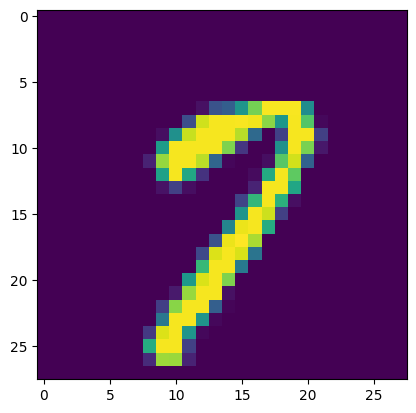

In [7]:
plt.imshow(x_train[9999])

In [8]:
model=keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [10]:
history=model.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9205 - loss: 0.2781 - val_accuracy: 0.9655 - val_loss: 0.1190
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9642 - loss: 0.1229 - val_accuracy: 0.9735 - val_loss: 0.0942
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9748 - loss: 0.0838 - val_accuracy: 0.9767 - val_loss: 0.0794
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9807 - loss: 0.0631 - val_accuracy: 0.9790 - val_loss: 0.0721
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9854 - loss: 0.0492 - val_accuracy: 0.9795 - val_loss: 0.0734
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.9798 - val_loss: 0.0725
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9911 - loss: 0.0297 - val_accuracy: 0.9810 - val_loss: 0.0739
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9926 - loss: 0.0241 -

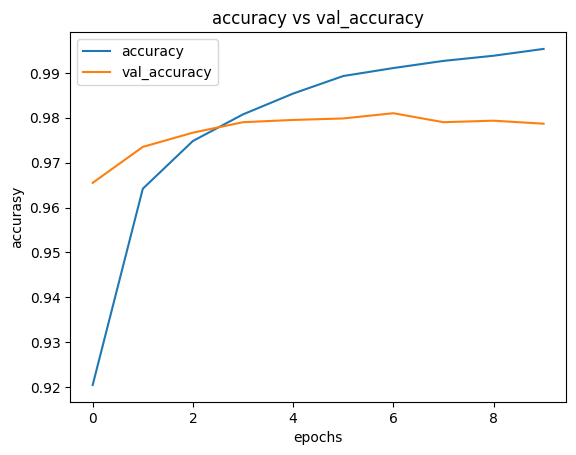

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('accuracy vs val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accurasy')
plt.legend(['accuracy', 'val_accuracy'])

In [12]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
y_pred[777]

array([1.7093136e-13, 9.9994856e-01, 1.3025775e-08, 3.1610587e-05,
       7.5406277e-08, 8.1844656e-11, 2.5331271e-12, 5.7605396e-09,
       1.9618195e-05, 2.4515212e-09], dtype=float32)

In [14]:
import numpy as np

y_pred=np.argmax(y_pred, axis=1)

In [15]:
y_pred[33]

np.int64(4)

In [16]:
y_test[33]

np.uint8(4)

Text(0.5, 1.0, 'y_test: 4, y_pred:4')

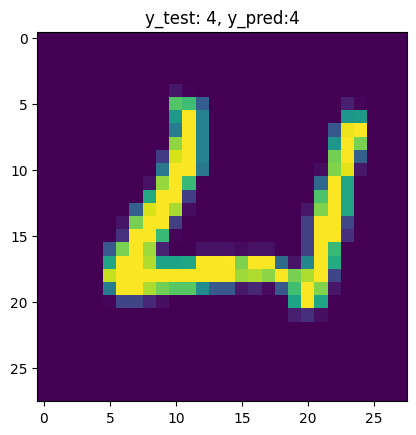

In [17]:
plt.imshow(x_test[33])
plt.title(f'y_test: {y_test[33]}, y_pred:{y_pred[33]}')

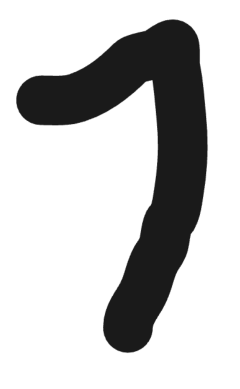

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/Screenshot 2026-06-04 at 10.09.11.png')

plt.imshow(img)
plt.axis('off')
plt.show()

In [20]:
x_test[33].shape

(28, 28)

In [21]:
import cv2

In [55]:
img=cv2.imread('/content/Screenshot 2026-06-04 at 10.46.49.png', 0)

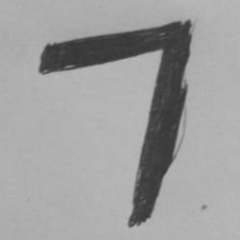

In [56]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [57]:
img.shape

(240, 240)

In [63]:

img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

img_normalized = img_resized / 255.0

img_input = img_normalized.reshape(1,28, 28, 1)

print(f"Original image shape: {img.shape}")
print(f"Resized image shape: {img_resized.shape}")
print(f"Final input shape for model: {img_input.shape}")

Original image shape: (240, 240)
Resized image shape: (28, 28)
Final input shape for model: (1, 28, 28, 1)


In [64]:
op = model(img_input, training=False)

print(op)

tf.Tensor(
[[1.1117938e-18 6.2867499e-22 9.9677438e-01 6.6669905e-09 0.0000000e+00
  3.2256073e-03 3.8332896e-08 3.5315986e-09 5.8358214e-12 6.9466183e-16]], shape=(1, 10), dtype=float32)


In [65]:
print(np.argmax(op))

2


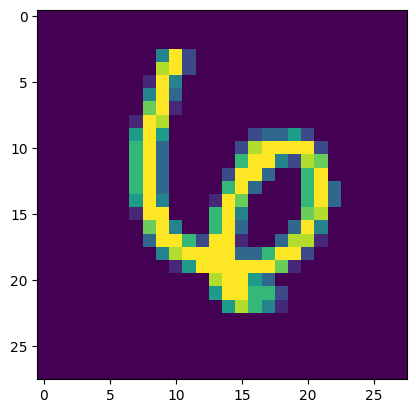

In [61]:
plt.imshow(x_test[22])

In [62]:
# model.save('mnistmodel1.h5')